Note: Decided to run the replication code in the colab envirnment due to gpu restrictions on our peronal computers. Therefore, we also had to reduce some paremeters (as specified in step 1) during the replication in order to achive similar results to the paper.

In [3]:
import os, re, random
import pandas as pd
from sklearn.datasets import fetch_openml
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
)
import torch

In [4]:
# ---------- GLOBAl CONFIGS ----------
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
random.seed(42)

# Setting DEVICE to be dynamic (uses GPU if available, else CPU)
if torch.cuda.is_available():
    torch.set_default_device("cuda")
    DEVICE = torch.device("cuda")
    print("Using GPU")
else:
    torch.set_default_device("cpu")
    DEVICE = torch.device("cpu")
    print("Using CPU - GPU is currently unavilable")

# --- Values Taken from Paper Specifications ---
MODEL_NAME = "distilgpt2"   # stays no matter the dataset chosen
MAX_LEN = 256               # not explicitly specified but is assumed
BATCH_SIZE = 32             # (32 is specified in the paper - stays no matter the dataset chosen)
EPOCHS = 10                 # (50 is specified in the paper - stays no matter the dataset chosen)
N_SAMPLES = 2000            # (5000 specified in the paper for the adult dataset) # rows we want in our synthetic dataset

# --- Loading the Two Chosen Datasets ---
# -- Comment out the one not in use --
# - Adult Dataset -
DATASET_NAME = "adult"
LABEL_ORIG = "class"
LABEL_NEW = "income"
CSV_OUT = "data/synthetic_adult_predllm_mini.csv"

# - Bank Dataset -
# DATASET_NAME = "bank"
# LABEL_ORIG = "bank-marketing"
# LABEL_NEW = "y"
# CSV_OUT = "data/synthetic_bank_predllm_mini.csv"


print(f" --- Loading Dataset: {DATASET_NAME} --- ")
chosen_dataset = fetch_openml(DATASET_NAME, version=2, as_frame=True)
df = chosen_dataset.frame
df = df.rename(columns={LABEL_ORIG: LABEL_NEW})  # renamed in the df
LABEL = LABEL_NEW                                # setting it for the rest of the pipeline
df = df.dropna().reset_index(drop=True)

df = df.sample(n=min(2000, len(df)), random_state=42).reset_index(drop=True) # keeps a smaller subset (computationally easier on our laptops)

FEATURES = [c for c in df.columns if c != LABEL]    # creates a list of column names but excludes the target LABEL value, this is bc we are trying to predict that label

Using GPU
 --- Loading Dataset: adult --- 


In [5]:
# STEP 1
# ---------- Serialization helpers: Fine-tune with Y last + Permute - learn p(Y｜X） ----------
def serialize_row(row: pd.Series, feature_order, label_col: str) -> str:
    ''' Used to help the model understand the data.
        The input data is currently a key value pair,
        but inorder for it to actually understand and process it, it converts it to string format.
    '''
    parts = []
    for col in feature_order:
        parts.append(f"{col} is {str(row[col]).strip()}")
    parts.append(f"{label_col} is {str(row[label_col]).strip()}")
    return ", ".join(parts)

def build_training_corpus(df: pd.DataFrame, features, label_col, permute_ratio=0.7):
    ''' Used to shuffle the order around of the passed in serialized string but
    makes sure that the LABEL value is always last. This helps with the training process.
    '''
    texts = []
    for _, r in df.iterrows():
        texts.append(serialize_row(r, features, label_col))  # original
        if random.random() < permute_ratio:
            fperm = features[:]
            random.shuffle(fperm)
            texts.append(serialize_row(r, fperm, label_col))  # shuffled
    return texts

print("Building training texts…")
train_texts = build_training_corpus(df, FEATURES, LABEL, permute_ratio=0.7)
print(train_texts)

# ---------- Tokenization + Training ----------
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

enc = tok(
    train_texts,
    padding = True,
    truncation = True,
    max_length = MAX_LEN,
    return_tensors = "pt",
)

class TxtDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.enc = encodings
    def __len__(self):
        return self.enc["input_ids"].shape[0]
    def __getitem__(self, i):
        return {
            "input_ids": self.enc["input_ids"][i],
            "attention_mask": self.enc["attention_mask"][i],
            "labels": self.enc["input_ids"][i],
        }

ds = TxtDataset(enc)

# --- Model Specifications ---
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.to(DEVICE)

# --- Training Specifications ---
# -- Described earlier in the code --
args = TrainingArguments(
    output_dir = "runs/predllm-mini",
    per_device_train_batch_size = BATCH_SIZE,
    gradient_accumulation_steps=8,
    num_train_epochs = EPOCHS,
    learning_rate = 5e-5,
    weight_decay = 0.01,
    fp16 = torch.cuda.is_available(),
    bf16 = False,
    logging_steps = 50,
    save_steps = 2000,
    save_total_limit = 1,
    report_to = [],
    no_cuda = not torch.cuda.is_available(),  # only disable CUDA if GPU isn't available
    dataloader_pin_memory = False,
    # use_mps_device=False,     # only needed if running on a mac
)

print("Initializing the trainer...")
trainer = Trainer(model=model, args=args, train_dataset=ds)
print(trainer)

print("Fine-tuning (CPU/GPU - depending on which one is selected to run on)")
trainer.train()   # startes training
model = trainer.model
model.to(DEVICE)
model.eval()

print("Model is on device - ", next(model.parameters()).device)

# --- Saves Finetuning Data to the 'runs' Folder ---
os.makedirs("runs/predllm-mini/model", exist_ok=True)
trainer.save_model("runs/predllm-mini/model")
tok.save_pretrained("runs/predllm-mini/model")

Building training texts…
['age is 19, workclass is Self-emp-not-inc, fnlwgt is 30800, education is 10th, education-num is 6, marital-status is Married-spouse-absent, occupation is Adm-clerical, relationship is Unmarried, race is Amer-Indian-Eskimo, sex is Female, capital-gain is 0, capital-loss is 0, hours-per-week is 40, native-country is United-States, income is <=50K', 'sex is Female, relationship is Unmarried, race is Amer-Indian-Eskimo, native-country is United-States, hours-per-week is 40, occupation is Adm-clerical, marital-status is Married-spouse-absent, workclass is Self-emp-not-inc, fnlwgt is 30800, capital-gain is 0, education is 10th, education-num is 6, capital-loss is 0, age is 19, income is <=50K', 'age is 45, workclass is Private, fnlwgt is 26781, education is HS-grad, education-num is 9, marital-status is Married-civ-spouse, occupation is Farming-fishing, relationship is Husband, race is Amer-Indian-Eskimo, sex is Male, capital-gain is 0, capital-loss is 0, hours-per-

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

Initializing the trainer...
Fine-tuning (CPU/GPU - depending on which one is selected to run on)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
50,1.437900
100,0.504900


Model is on device -  cuda:0


('runs/predllm-mini/model/tokenizer_config.json',
 'runs/predllm-mini/model/special_tokens_map.json',
 'runs/predllm-mini/model/vocab.json',
 'runs/predllm-mini/model/merges.txt',
 'runs/predllm-mini/model/added_tokens.json',
 'runs/predllm-mini/model/tokenizer.json')

In [8]:
# STEP 2
# ---------- Feature conditional Sampling phase: generate X ONLY ----------
print("\nSampling synthetic features (X) …")

def sample_feature_value(col):
    '''Sampler from real data'''
    return random.choice(df[col].tolist())

def generate_features_only(start_feature, start_value, max_new_tokens=120):
    """
    Start with "feature is value" and let the model continue generating
    features. If we see the label field begin (`, income is`), we cut before it.
    Returns a partial dict of generated features.
    """
    start = f"{start_feature} is {start_value}"
    prompt = start
    print(f"\n[Prompt Start] {prompt}")
    inputs = tok(prompt, return_tensors = "pt").to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens = max_new_tokens,
        do_sample = True,
        temperature = 0.8,
        top_p = 0.95,
        pad_token_id = tok.eos_token_id,
        eos_token_id = tok.eos_token_id,
    )
    text = tok.decode(out[0], skip_special_tokens=True)
    print(f"[Raw Output] {text}")

    # Stop at the beginning of label if present
    stop_idx = text.find(f", {LABEL} is")
    if stop_idx != -1:
        text = text[:stop_idx]
        print(f"[Truncated at label] {text}")

    # Parse comma separated "name is value" clauses
    clauses = [c.strip() for c in text.split(",")]
    seen = {}
    for c in clauses:
        m = re.match(r"^([^,]+?)\s+is\s+(.+)$", c)
        if not m:
            continue
        name = m.group(1).strip()
        val = m.group(2).strip()
        if name in FEATURES and name not in seen:
            seen[name] = val
        if len(seen) == len(FEATURES):
            break
    print(f"[Parsed Features] {seen}")
    return seen

synthetic_X = []
for i in range(N_SAMPLES):
    f0 = random.choice(FEATURES)      # randomly selects a feature
    v0 = sample_feature_value(f0)     # randomly selects a value
    print(f"\n[Sample {i+1}] Starting from: {f0} is {v0}")
    feats = generate_features_only(f0, v0)
    # Fill any missing features from real marginals to keep schema complete
    for col in FEATURES:
        if col not in feats:
            feats[col] = sample_feature_value(col)
            print(f"[Filled Missing Feature] {col} with {feats[col]}")
    synthetic_X.append(feats)

print(f"Generated {len(synthetic_X)} synthetic feature rows.")


Streaming output truncated to the last 5000 lines.
[Sample 1482] Starting from: workclass is Private

[Prompt Start] workclass is Private
[Raw Output] workclass is Private, relationship is Husband, capital-gain is 0, age is 55, native-country is United-States, education is Some-college, workclass is Private, marital-status is Married-civ-spouse, hours-per-week is 50, fnlwgt is 272213, native-country is United-States, occupation is Machine-op-inspct, sex is Male, income is <=50K
[Truncated at label] workclass is Private, relationship is Husband, capital-gain is 0, age is 55, native-country is United-States, education is Some-college, workclass is Private, marital-status is Married-civ-spouse, hours-per-week is 50, fnlwgt is 272213, native-country is United-States, occupation is Machine-op-inspct, sex is Male
[Parsed Features] {'workclass': 'Private', 'relationship': 'Husband', 'capital-gain': '0', 'age': '55', 'native-country': 'United-States', 'education': 'Some-college', 'marital-stat

In [10]:
# STEP 3
# ---------- Label-query phase: get Y (Patch 1: tighter parsing) ----------
print("\nQuerying labels (Y) …")

VALID_LABELS = {"<=50K", ">50K"}

def label_query(feat_row: dict) -> str:
  '''Serializes features in the original order,
  then lets the model continue to produce "income is <value>
  '''

  # Builds the prompt: 'feature is value, feature is value, ...'
  parts = [f"{c} is {feat_row[c]}" for c in FEATURES]
  prompt = ", ".join(parts) + ", "
  print(f"\n Prompt to model {prompt}")

  inputs = tok(prompt, return_tensors="pt").to(model.device)

  # Runs the model
  out = model.generate(
  **inputs,
  max_new_tokens = 8,
  do_sample = False,
  temperature = 0.0,
  top_p = 1.0,
  pad_token_id = tok.eos_token_id,
  eos_token_id = tok.eos_token_id,
)

  text = tok.decode(out[0], skip_special_tokens=True)
  print(f"[Model Output] {text}")

  for v in VALID_LABELS:                # orders the known labels first
    if f"{LABEL} is {v}" in text:
      print(f"Label found {v}")
      return v

  m = re.search(rf"{LABEL}\s+is\s+([^\s,]+)", text)      # regex used to fix any formatting issues
  if m:
    cand = m.group(1).strip()
    cand = cand.replace(".", "")        # normalization in case of punctuation
    for v in VALID_LABELS:
      if cand.lower() == v.lower():
        print(f"Fallback label {v}")
        return v

  print("No label found - switching to random label")
  return None

# --- Runs the label quesries ont he rows ---
synthetic_rows = []

print(f"\n Labeling {len(synthetic_X)} synthetic rows...")
for i, fx in enumerate(synthetic_X):
  print(f"\n Row {i+1}")
  y = label_query(fx)

  if y is None:     # no labels detected
      y = random.choice(df[LABEL].tolist())
      print(f"Randomly selected label: {y}")

  synthetic_rows.append({**fx, LABEL: y})

  print(f" Completed labeling {i+1} / {len(synthetic_X)} rows...")


#--- Saves Synthetic CSV ---

syn_df = pd.DataFrame(synthetic_rows)

os.makedirs("data", exist_ok=True)
syn_df.to_csv(CSV_OUT, index=False)
print(f"\nSaved synthetic dataset to: {CSV_OUT}")

print("\nSample synthetic rows:")
print(syn_df.head(10).to_string(index=False))


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Streaming output truncated to the last 5000 lines.
 Completed labeling 1377 / 2000 rows...

 Row 1378

 Prompt to model age is 55, workclass is Private, fnlwgt is 203878, education is HS-grad, education-num is 10, marital-status is Divorced, occupation is Other-service, relationship is Own-child, race is White, sex is Male, capital-gain is 0, capital-loss is 0, hours-per-week is 30, native-country is United-States, 
[Model Output] age is 55, workclass is Private, fnlwgt is 203878, education is HS-grad, education-num is 10, marital-status is Divorced, occupation is Other-service, relationship is Own-child, race is White, sex is Male, capital-gain is 0, capital-loss is 0, hours-per-week is 30, native-country is United-States, urn-country is United-States,
No label found - switching to random label
Randomly selected label: <=50K
 Completed labeling 1378 / 2000 rows...

 Row 1379

 Prompt to model age is 23, workclass is Private, fnlwgt is 286701, education is Bachelors, education-num is 9

In [22]:
# STEP 4
# ----------  TSTR: Train on Synthetic, Test on Real ----------
print("\nRunning TSTR (Train on Synthetic Test on Real)…")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Copies real and synthetic data for processing
real = df.copy()
real_y = real[LABEL]
real_X = real.drop(columns=[LABEL])

syn = syn_df.copy()
syn_y = syn[LABEL].fillna("<=50K")
syn_X = syn.drop(columns=[LABEL])

print("Real and synthetic datasets loaded and separated into features/labels.")

# Identifies categorical/numerical columns from REAL schema
cat_cols = [c for c in real_X.columns if real_X[c].dtype == 'object']
num_cols = [c for c in real_X.columns if c not in cat_cols]
print(f"Found {len(cat_cols)} categorical and {len(num_cols)} numerical columns.")

for col in num_cols:
    real_X[col] = pd.to_numeric(real_X[col], errors="coerce")
    syn_X[col]  = pd.to_numeric(syn_X[col],  errors="coerce")

print("\nFilling NaNs with real-data medians...")
real_medians = real_X[num_cols].median(numeric_only=True)
real_X[num_cols] = real_X[num_cols].fillna(real_medians)
syn_X[num_cols]  = syn_X[num_cols].fillna(real_medians)

# (Optional but robust): ensure categoricals are strings for OneHotEncoder
for col in cat_cols:
    real_X[col] = real_X[col].astype(str)
    syn_X[col]  = syn_X[col].astype(str)

print("Finsihed data cleaning now building the preprocessing pipeline...")

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

# Defines the model
clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    n_jobs=4
)

pipe = Pipeline([("pre", pre), ("clf", clf)])
print("Preprocessing and model processing...")
print("\n")

print("Now encodoing the synthetic labels.")
label_map = {"<=50K": 0, ">50K": 1}
inv_label_map = {v: k for k, v in label_map.items()}

syn_y_enc = syn_y.map(label_map)
if syn_y_enc.isna().any():
    maj = syn_y_enc.value_counts().idxmax()
    syn_y_enc = syn_y_enc.fillna(maj).astype(int)
else:
    syn_y_enc = syn_y_enc.astype(int)
print("Synthetic labels encoded...")

# Real test split
_, X_test_real, _, y_test_real = train_test_split(
    real_X, real_y, test_size=0.2, stratify=real_y, random_state=42
)
y_test_real_enc = y_test_real.map(label_map).astype(int)

print("Training of synthetic data...")
pipe.fit(syn_X, syn_y_enc)

print("Predicting on real data now...")
pred_enc = pipe.predict(X_test_real).astype(int)
acc = accuracy_score(y_test_real_enc, pred_enc)
print(f"TSTR Accuracy (trained on synthetic, tested on real): {acc:.3f}")

# Predicted label distribution in natural labels
pred_labels = pd.Series(pred_enc).map(inv_label_map).value_counts(normalize=True).rename("pred_label_share")
print("\nPredicted label share on real test set:")
print(pred_labels.to_string())

print("Majority baseline accuracy:", (y_test_real_enc.value_counts().max() / len(y_test_real_enc)))
print("\n")
print("Successfully fine-tuned LM, synthetic CSV, and a TSTR score.")





Running TSTR (Train on Synthetic Test on Real)…
Real and synthetic datasets loaded and separated into features/labels.
Found 0 categorical and 14 numerical columns.

Filling NaNs with real-data medians...
Finsihed data cleaning now building the preprocessing pipeline...
Preprocessing and model processing...


Now encodoing the synthetic labels.
Synthetic labels encoded...
Training of synthetic data...
Predicting on real data now...
TSTR Accuracy (trained on synthetic, tested on real): 0.688

Predicted label share on real test set:
<=50K    0.8975
>50K     0.1025
Majority baseline accuracy: 0.745


Successfully fine-tuned LM, synthetic CSV, and a TSTR score.


**Evaluations**

In [49]:
import numpy as np
import pandas as pd
from typing import Tuple, Optional


from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# Define real_df and synth_df
real_df = real_X
synth_df = syn_X

# Converts the existing DataFrames to aligned numeric matrices
X_real = real_df.select_dtypes(include=[np.number]).copy()
X_synth = synth_df.select_dtypes(include=[np.number]).copy()

# Ensures same columns and order
common_cols = [c for c in X_real.columns if c in X_synth.columns]
X_real = X_real[common_cols].to_numpy()
X_synth = X_synth[common_cols].to_numpy()

print("X_real and X_synth ready:", X_real.shape, X_synth.shape)


X_real and X_synth ready: (2000, 14) (2000, 14)


In [32]:
# -- Set Up --
try:
    from xgboost import XGBClassifier
    _HAS_XGB = True
except Exception:
    _HAS_XGB = False
from sklearn.linear_model import LogisticRegression

def _as_array(X) -> np.ndarray:
    if isinstance(X, pd.DataFrame):
        return X.values
    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError("Expected 2D array for features.")
    return X

def _ensure_numeric_2d(X_real, X_synth) -> Tuple[np.ndarray, np.ndarray]:
  '''Ensures that all data is clean and formatted properly '''
  Xr = _as_array(X_real)
  Xs = _as_array(X_synth)

  # basic shape checks
  if Xr.shape[1] != Xs.shape[1]:
      raise ValueError(f"Column mismatch: X_real has {Xr.shape[1]} cols, X_synth has {Xs.shape[1]}.")

  # impute NaN/inf
  Xr = np.where(np.isfinite(Xr), Xr, np.nan)
  Xs = np.where(np.isfinite(Xs), Xs, np.nan)

  imputer = SimpleImputer(strategy="most_frequent")
  Xr = imputer.fit_transform(Xr)
  Xs = imputer.transform(Xs)

  Xr = Xr.astype(float)
  Xs = Xs.astype(float)

  print("Preprocessing complete for numeric 2D arrays.")
  return Xr, Xs

def _safe_k(n: int, k: int) -> int:
  '''Ensure kNN uses k <= n-1 and k>=1.'''
  if n <= 1:
      raise ValueError("Not enough rows for kNN metrics.")
  return max(1, min(k, max(1, n-1)))

def _kth_nn_radius(X: np.ndarray, k: int = 5) -> np.ndarray:
  '''Computes the k-th nearest neighbor radius for each row'''
  k_adj = _safe_k(len(X), k)
  nn = NearestNeighbors(n_neighbors=k_adj+1).fit(X)
  dists, _ = nn.kneighbors(X)     # excludes self; picks the k-th nearest neighbor
  return dists[:, -1]

# --- Inverse-KL with numeric or categorical columns ---
def _safe_probs(counts: np.ndarray) -> np.ndarray:
  '''Normalizses the count arrays '''
  counts = np.asarray(counts, dtype=float)
  s = counts.sum()
  if s <= 0:
      return np.ones_like(counts) / len(counts)
  return counts / s

def _inv_kl_1d(real_col, synth_col, max_bins: int = 30) -> float:
    eps = 1e-8
    try:
        real_num = pd.to_numeric(pd.Series(real_col), errors="raise")
        synth_num = pd.to_numeric(pd.Series(synth_col), errors="raise")
        is_numeric = True
    except Exception:
        is_numeric = False

    if is_numeric:
        real = real_num.astype(float).values
        synth = pd.Series(synth_num).astype(float).values

        q25, q75 = np.nanpercentile(real, [25, 75])
        iqr = max(q75 - q25, eps)
        bin_width = 2 * iqr * (len(real) ** (-1/3))
        if not np.isfinite(bin_width) or bin_width <= 0:
            bins = min(max_bins, max(5, int(np.sqrt(max(len(real), 5)))))
        else:
            rng = np.nanmax(real) - np.nanmin(real)
            bins = int(np.clip(rng / max(bin_width, eps), 5, max_bins))

        hist_r, edges = np.histogram(real, bins=bins)
        hist_s, _ = np.histogram(synth, bins=edges)

        p = _safe_probs(hist_r + 1)  # Laplace smoothing
        q = _safe_probs(hist_s + 1)
    else:
        r_counts = pd.Series(real_col).astype("object").value_counts()
        s_counts = pd.Series(synth_col).astype("object").value_counts()
        cats = pd.Index(sorted(set(r_counts.index).union(set(s_counts.index))))
        r = (r_counts.reindex(cats).fillna(0).values + 1)
        s = (s_counts.reindex(cats).fillna(0).values + 1)
        p = r / r.sum()
        q = s / s.sum()

    kl = float(np.sum(p * np.log((p + eps) / (q + eps))))
    inv_kl = 1.0 / (1.0 + max(kl, 0.0))  # higher is better
    return inv_kl

def inverse_kl_dataframe(real_df: pd.DataFrame, synth_df: pd.DataFrame):
  '''Inverse-KL on an entire dataframe'''
  if list(real_df.columns) != list(synth_df.columns):
      raise ValueError("Inverse-KL: dataframes must have the same columns in the same order.")
  print("Computing inverse-KL for each column...")
  vals = []
  for c in real_df.columns:
      vals.append(_inv_kl_1d(real_df[c].values, synth_df[c].values))
  return float(np.mean(vals)), pd.Series(vals, index=real_df.columns).sort_values(ascending=True)

print("Expecting variables X_real and X_synth to be defined (numeric, 2D).")


Expecting variables X_real and X_synth to be defined (numeric, 2D).


In [36]:
# --- DISCRIMINATOR SCORE (real vs synthetic) ---
print("\n--- DISCRIMINATOR SCORE (Real vs Synthetic Classifier) ---")
Xr, Xs = _ensure_numeric_2d(X_real, X_synth)
X_disc = np.vstack([Xr, Xs])
y_disc = np.concatenate([np.ones(len(Xr), dtype=int), np.zeros(len(Xs), dtype=int)])
test_size = 0.3 if len(X_disc) >= 20 else 0.5
print(f" Splitting data into train/test with test_size={test_size:.2f}")
X_tr, X_te, y_tr, y_te = train_test_split(X_disc, y_disc, test_size=test_size, stratify=y_disc, random_state=42)
print(f" Train size: {X_tr.shape[0]} | Test size: {X_te.shape[0]}")

if _HAS_XGB:
    clf = XGBClassifier(
        n_estimators=300, max_depth=6, subsample=0.8, colsample_bytree=0.8,
        learning_rate=0.05, reg_lambda=1.0, n_jobs=-1, random_state=42
    )
else:
    clf = LogisticRegression(max_iter=2000, n_jobs=-1, solver="lbfgs")

clf.fit(X_tr, y_tr)
print("\nModel training complete.")

print("Predicting labels on test set...")
y_pred = clf.predict(X_te)

try:
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_te)[:, 1]
    elif hasattr(clf, "decision_function"):
        from sklearn.metrics import roc_curve
        scores = clf.decision_function(X_te)
        ranks = pd.Series(scores).rank(method="average").values
        y_prob = (ranks - ranks.min()) / (ranks.max() - ranks.min() + 1e-8)
    else:
      print("No probability scores available from this classifier.")
      y_prob = None
except Exception as e:
  print(f"Error computing probabilities: {e}")
  y_prob = None

acc = accuracy_score(y_te, y_pred)
if y_prob is not None:
    auc = roc_auc_score(y_te, y_prob)
    print(f"\nDiscriminator score — Accuracy: {acc:.3f}   AUC: {auc:.3f}   (~0.50 acc is better)")
else:
    print(f"\nDiscriminator score — Accuracy: {acc:.3f}   (~0.50 is better; AUC not available)")



--- DISCRIMINATOR SCORE (Real vs Synthetic Classifier) ---
Preprocessing complete for numeric 2D arrays.
 Splitting data into train/test with test_size=0.30
 Train size: 2800 | Test size: 1200


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  3  5  6  7  8  9 13]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  3  5  6  7  8  9 13]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(



Model training complete.
Predicting labels on test set...

Discriminator score — Accuracy: 0.653   AUC: 0.714   (~0.50 acc is better)


In [47]:
# DENSITY (kNN; higher is better if synth lies in real neighborhoods)
print("\n--- DENSITY (kNN ) ---")
Xr, Xs = _ensure_numeric_2d(X_real, X_synth)

# Choose k value and adjust for data size
k = 5
k_real = _safe_k(len(Xr), k)

scaler = StandardScaler().fit(Xr)  # scale by real distribution
R = scaler.transform(Xr)
S = scaler.transform(Xs)

r_real = _kth_nn_radius(R, k=k_real)

nn_real = NearestNeighbors(n_neighbors=1).fit(R)
d_sr, idx_sr = nn_real.kneighbors(S, return_distance=True)
d_sr = d_sr.ravel()
idx_sr = idx_sr.ravel()

hits = (d_sr <= r_real[idx_sr]).astype(float)
density_score = float(hits.mean())
print(f"Density (k={k_real}) = {density_score:.3f}   # higher = synthetic near real localities")



--- DENSITY (kNN ) ---
Preprocessing complete for numeric 2D arrays.
Density (k=5) = 0.943   # higher = synthetic near real localities


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  3  5  6  7  8  9 13]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  3  5  6  7  8  9 13]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [40]:
# COVERAGE (kNN; higher is better if synthetic spans real space)
print("\n--- CONVERGE (kNN ) ---")
Xr, Xs = _ensure_numeric_2d(X_real, X_synth)

k = 5
k_synth = _safe_k(len(Xs), k)

scaler = StandardScaler().fit(Xr)  # measure in real-scaled space
R = scaler.transform(Xr)
S = scaler.transform(Xs)

r_synth = _kth_nn_radius(S, k=k_synth)

nn_synth = NearestNeighbors(n_neighbors=1).fit(S)
d_rs, idx_rs = nn_synth.kneighbors(R, return_distance=True)
d_rs = d_rs.ravel()
idx_rs = idx_rs.ravel()

covered = (d_rs <= r_synth[idx_rs]).astype(float)
coverage_score = float(covered.mean())
print(f"Coverage (k={k_synth}) = {coverage_score:.3f}   # higher = synthetic covers real modes")



--- CONVERGE (kNN ) ---
Preprocessing complete for numeric 2D arrays.
Coverage (k=5) = 0.815   # higher = synthetic covers real modes


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  3  5  6  7  8  9 13]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  3  5  6  7  8  9 13]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [45]:
# INVERSE KL DIVERGENCE (per-feature, averaged)

print("\n--- INVERSE KL DIVERGENCE ---")
def _to_aligned_dataframes(X_real, X_synth) -> Tuple[pd.DataFrame, pd.DataFrame]:
  ''' Ensures X_real and X_synth are in the same format and aligned column-wise.
    If already DataFrames, checks column order.
    If arrays, creates default column names.'''

  if isinstance(X_real, pd.DataFrame) and isinstance(X_synth, pd.DataFrame):
      if list(X_real.columns) != list(X_synth.columns):
          raise ValueError("Inverse-KL: DataFrames must share identical columns in order.")
      return X_real.reset_index(drop=True), X_synth.reset_index(drop=True)

  print("Converting arrays to DataFrames...")
  Xr, Xs = _ensure_numeric_2d(X_real, X_synth)
  cols = [f"f{i}" for i in range(Xr.shape[1])]
  return pd.DataFrame(Xr, columns=cols), pd.DataFrame(Xs, columns=cols)

print("Aligning columns across real and synthetic data...")
real_df, synth_df = _to_aligned_dataframes(X_real, X_synth)

print("Calculating per-feature inverse KL divergence scores...")
inv_kl_mean, inv_kl_per_col = inverse_kl_dataframe(real_df, synth_df)

print(f"\nInverse KL (mean across features) = {inv_kl_mean:.3f}   # higher = closer per-feature distributions")



--- INVERSE KL DIVERGENCE ---
Aligning columns across real and synthetic data...
Converting arrays to DataFrames...
Preprocessing complete for numeric 2D arrays.
Calculating per-feature inverse KL divergence scores...
Computing inverse-KL for each column...

Inverse KL (mean across features) = 0.938   # higher = closer per-feature distributions


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  3  5  6  7  8  9 13]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  3  5  6  7  8  9 13]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [48]:


# --- Collects metric values from previous cells ---
results = {
    'Discriminator score': acc if 'acc' in locals() else None,
    'Inverse KL': inv_kl_mean if 'inv_kl_mean' in locals() else None,
    'Density': density_score if 'density_score' in locals() else None,
    'Coverage': coverage_score if 'coverage_score' in locals() else None
}

for metric, value in results.items():
    df = pd.DataFrame({'Pred-LLM': [value]})
    print(f"\n{metric}")
    display(df)


Discriminator score


,Pred-LLM
0,0.653333



Inverse KL


,Pred-LLM
0,0.937885



Density


,Pred-LLM
0,0.9425



Coverage


,Pred-LLM
0,0.815


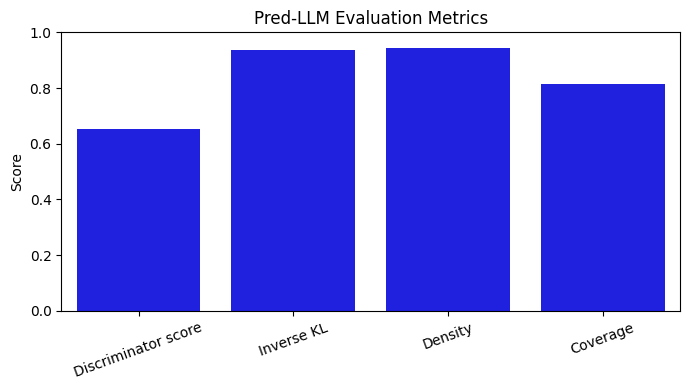

In [50]:
# - Prepares the data for plotting ---
df_results = pd.DataFrame(list(results.items()), columns=["Metric", "Pred-LLM"])

plt.figure(figsize=(7, 4))
sns.barplot(data=df_results, x="Metric", y="Pred-LLM", color="blue")
plt.title("Pred-LLM Evaluation Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()